In [94]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from scipy.stats import spearmanr
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import RandomizedSearchCV

In [98]:
# Ridge Regression Model
df = pd.read_parquet('train_dataset_quarterly.parquet')
tscv = TimeSeriesSplit(n_splits=5)

PRICE_FEATURES = ["sma_20","sma_50","sma_200","ema_12","ema_26","rsi_14",
                  "adx_14","atr_14","macd_hist","stoch_k_14","stoch_d_14","cci_20",
                  "stddev_252","max_drawdown_252",
                  "price_to_sma20","price_to_sma50","price_to_sma200","atr_pct"]

FUND_FEATURES = ["roe","roa","debt_equity","current_ratio","cash_to_assets","fcf_to_assets"]

ALL_FEATURES = PRICE_FEATURES + FUND_FEATURES

EXCLUDED_TICKERS = {"NBIS", "BRK.B", "AMBP", "CRM", "BE"}
TICKERS = sorted(set(df["ticker"].unique()) - EXCLUDED_TICKERS)

PRICE_FEATURES = ["sma_20","sma_50","sma_200","ema_12","ema_26","rsi_14",
                  "adx_14","atr_14","macd_hist","stoch_k_14","stoch_d_14","cci_20",
                  "stddev_252","max_drawdown_252",
                  "price_to_sma20","price_to_sma50","price_to_sma200","atr_pct"]

FUND_FEATURES = ["roe","roa","debt_equity","current_ratio","cash_to_assets","fcf_to_assets"]

ALL_FEATURES = PRICE_FEATURES + FUND_FEATURES

model_df = df[df["ticker"].isin(TICKERS)].dropna(subset=ALL_FEATURES + ["target_return"])
X = model_df[ALL_FEATURES]
y = model_df["target_return"]
dates = model_df["date"]

train_mask = dates < "2021-06-01"
test_mask = dates >= "2021-06-01"

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alphas = np.linspace(1, 1000, 50)

ridge_cv = RidgeCV(alphas=alphas, cv=tscv)
ridge_cv.fit(X_train_scaled, y_train)

y_pred = ridge_cv.predict(X_test_scaled)

In [99]:
# Statistics — comparable per-date cross-sectional rank ICs (>=5 tickers/date)
def per_date_rank_ic(pred, actual, dates, min_n=5):
    frame = pd.DataFrame({"p": np.asarray(pred), "a": np.asarray(actual),
                          "d": np.asarray(dates)})
    out = [spearmanr(g["p"], g["a"]).statistic for _, g in frame.groupby("d") if len(g) >= min_n]
    return np.mean(out) if out else np.nan

ic_pooled = spearmanr(y_test, y_pred).statistic
ic_daily = per_date_rank_ic(y_pred, y_test, dates[test_mask])

dir_acc = (np.sign(y_pred) == np.sign(y_test)).mean()
baseline_up = (y_test > 0).mean()      # "always predict up" floor
print(f"Directional accuracy: {dir_acc:.1%}  (baseline 'always up': {baseline_up:.1%})")

# Trailing-momentum baselines: predict next-month return as the trailing 1m / 12m
# return — both known at prediction time. Evaluated with the SAME per-date
# procedure as the model, so the comparison is apples-to-apples.
test = model_df[test_mask].copy().sort_values(["ticker", "date"])
test["mom_1m"] = test.groupby("ticker")["close"].pct_change()
test["mom_12m"] = test.groupby("ticker")["close"].pct_change(12)

for label, col in [("momentum(1m)", "mom_1m"), ("momentum(12m)", "mom_12m")]:
    sub = test.dropna(subset=[col])
    y_i = sub["target_return"]
    print(f"  {label} baseline per-date IC: {per_date_rank_ic(sub[col], y_i, sub['date']):.4f}")

print("Best alpha selected:", ridge_cv.alpha_)
print(f"Model IC -> pooled: {ic_pooled:.4f}  | per-date (comparable): {ic_daily:.4f}")

Directional accuracy: 55.3%  (baseline 'always up': 56.9%)
  momentum(1m) baseline per-date IC: -0.0479
  momentum(12m) baseline per-date IC: 0.0064
Best alpha selected: 204.87755102040816
Model IC -> pooled: 0.0795  | per-date (comparable): 0.0921


In [100]:
def bucket_returns(returns, edges=(-0.05, 0.0, 0.05, 0.10), 
                    labels=("Strong Sell", "Sell", "Hold", "Buy", "Strong Buy")):
    """
    edges define the boundaries between buckets.
    Example with edges=(-0.05, 0, 0.05, 0.10):
      < -5%        -> Strong Sell
      -5% to 0%    -> Sell
      0% to 5%     -> Hold
      5% to 10%    -> Buy
      >= 10%       -> Strong Buy
    """
    bins = [-np.inf, *edges, np.inf]
    return pd.cut(returns, bins=bins, labels=labels)

# Apply to both actual and predicted returns using the SAME bucket edges
actual_buckets = bucket_returns(pd.Series(y_test).reset_index(drop=True))
pred_buckets   = bucket_returns(pd.Series(y_pred).reset_index(drop=True))

# Overall accuracy — exact bucket match
acc = accuracy_score(actual_buckets, pred_buckets)
print(f"Bucket classification accuracy: {acc:.2%}")

# Confusion matrix — shows WHERE the model gets it wrong (adjacent bucket vs wildly off)
labels_order = ["Strong Sell", "Sell", "Hold", "Buy", "Strong Buy"]
cm = confusion_matrix(actual_buckets, pred_buckets, labels=labels_order)
cm_df = pd.DataFrame(cm, index=[f"Actual: {l}" for l in labels_order],
                          columns=[f"Pred: {l}" for l in labels_order])
print(cm_df)

# Per-bucket precision/recall — check if some buckets have almost no predictions (support column)
print(classification_report(actual_buckets, pred_buckets, labels=labels_order, zero_division=0))

# Directional accuracy — a softer, often more meaningful metric: did we get the SIGN right?
directional_acc = (np.sign(y_test) == np.sign(y_pred)).mean()
print(f"Directional accuracy (up/down only): {directional_acc:.2%}")

Bucket classification accuracy: 15.98%
                     Pred: Strong Sell  Pred: Sell  Pred: Hold  Pred: Buy  \
Actual: Strong Sell                  2          48         263        102   
Actual: Sell                         1          16         149         39   
Actual: Hold                         3          37         139         31   
Actual: Buy                          1          15         128         37   
Actual: Strong Buy                   0          36         244        134   

                     Pred: Strong Buy  
Actual: Strong Sell                37  
Actual: Sell                        4  
Actual: Hold                       12  
Actual: Buy                         4  
Actual: Strong Buy                 51  
              precision    recall  f1-score   support

 Strong Sell       0.29      0.00      0.01       452
        Sell       0.11      0.08      0.09       209
        Hold       0.15      0.63      0.24       222
         Buy       0.11      0.20      0.

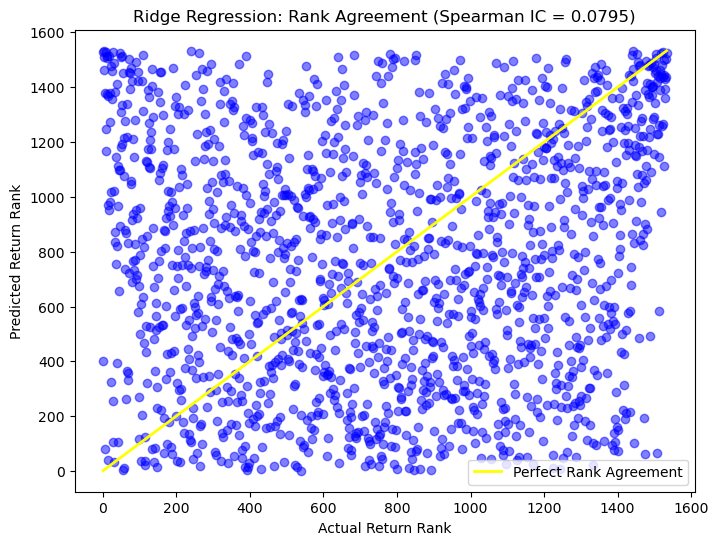

In [101]:
# Plot
# Note: normalize to arrays first — pd.Series(y_test) keeps a non-default index,
# which misaligns against the numpy prediction array (ValueError otherwise).
rank_actual = pd.Series(np.asarray(y_test)).rank().values
rank_pred = pd.Series(np.asarray(y_pred)).rank().values

plt.figure(figsize=(8, 6))
plt.scatter(rank_actual, rank_pred, color='blue', alpha=0.5)
plt.plot([rank_actual.min(), rank_actual.max()],
         [rank_actual.min(), rank_actual.max()],
         color='yellow', linewidth=2, label='Perfect Rank Agreement')
plt.xlabel("Actual Return Rank")
plt.ylabel("Predicted Return Rank")
plt.title(f"Ridge Regression: Rank Agreement (Spearman IC = {ic_pooled:.4f})")
plt.legend()
plt.show()

In [102]:
n = len(pd.unique(df['ticker']))
n

123